# Block-wise Scrambled Image Recognition Using Adaptation Network: quick start

Official implementation of the AAAI-20 Workshop (AIoT) paper by Koki Madono, Masayuki Tanaka, Masaki Onishi and Tetsuji Ogawa
([arXiv:2001.07761](https://arxiv.org/abs/2001.07761), [code](https://github.com/MADONOKOUKI/Block-wise-Scrambled-Image-Recognition)).

This notebook runs on a CPU in under a minute. It
1. scrambles an image with the four schemes compared in the paper (plain, LE, ELE, EtC) and decrypts it with the key, and
2. builds the proposed **ELE-AdaptNet + Shake-PyramidNet-110** and takes one training step on block-wise scrambled images.

In [1]:
# Install the package when running on Google Colab (locally: `pip install -e .` in the repository).
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/MADONOKOUKI/Block-wise-Scrambled-Image-Recognition"], check=True)

## 1. Block-wise scrambling

A 32x32 image is split into 8x8 = 64 blocks of 4x4 pixels (as for CIFAR in the paper).
**LE** shuffles and inverts the 4-bit halves of the pixel values with one key shared by all blocks,
**ELE** (proposed) uses a different key for every block and also shuffles the block locations,
**EtC** rotates/flips/inverts each block, changes its colour channels and shuffles block locations.
The key is the `seed`; `seed=30` reproduces the keys of the original code where they were seed-generated.

plain                      exact recovery: True
LE (Tanaka 2018)           exact recovery: True
ELE (proposed)             exact recovery: True


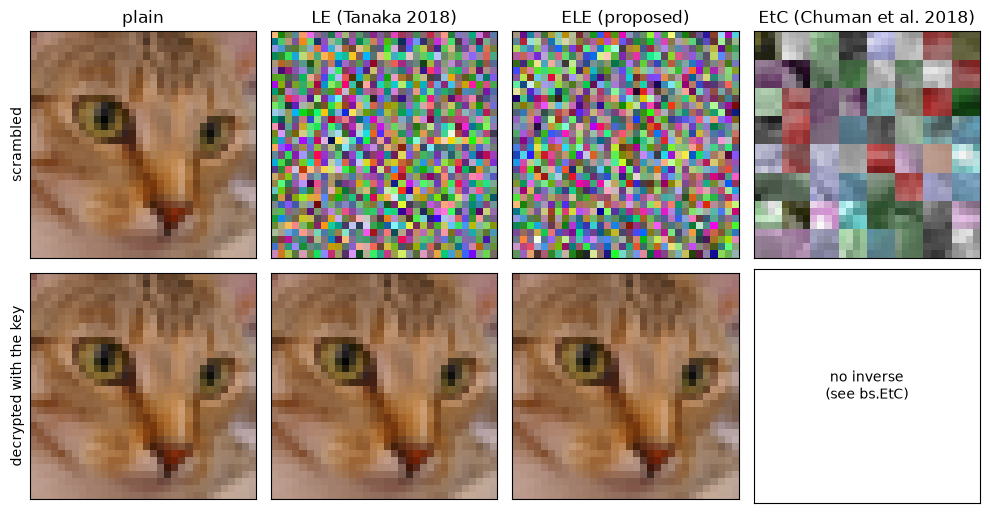

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data
import blockscramble as bs

cat = Image.fromarray(data.chelsea()[:, 75:375]).resize((32, 32), Image.BICUBIC)  # CIFAR-sized cat
img = np.asarray(cat)

schemes = {"plain": bs.Plain(), "LE (Tanaka 2018)": bs.LE(seed=30),
           "ELE (proposed)": bs.ELE(seed=30), "EtC (Chuman et al. 2018)": bs.EtC(seed=30)}
fig, axes = plt.subplots(2, 4, figsize=(10, 5.2))
for col, (name, scheme) in enumerate(schemes.items()):
    scrambled = scheme(img)
    axes[0, col].imshow(scrambled, interpolation="nearest"); axes[0, col].set_title(name)
    if scheme.invertible:
        axes[1, col].imshow(scheme.inverse(scrambled), interpolation="nearest")
        print(f"{name:26s} exact recovery: {np.array_equal(scheme.inverse(scrambled), img)}")
    else:
        axes[1, col].text(0.5, 0.5, "no inverse\n(see bs.EtC)", ha="center", va="center")
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("scrambled"); axes[1, 0].set_ylabel("decrypted with the key")
plt.tight_layout(); plt.show()

The EtC variant of the original code (used for Table 3) overwrites colour channels, so it cannot be
decrypted; `bs.EtC(channel_shuffle="permute")` is the invertible version with a true colour permutation.

Every scheme accepts PIL images, numpy arrays (`HxWxC`, `uint8` or float) and torch tensors (`CxHxW` / `NxCxHxW`),
so it can be used directly as a torchvision transform:

In [3]:
import torch
import torchvision.transforms as T

transform = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(), T.ToTensor(), bs.ELE(seed=30)])
x = transform(cat)
print(x.shape, x.dtype, float(x.min()), float(x.max()))

torch.Size([3, 32, 32]) torch.float32 0.0 1.0


## 2. ELE-AdaptNet + Shake-PyramidNet

The proposed adaptation network has one sub-network per block, a learnable pseudo permutation matrix $U$ that can undo
the block shuffling, and a pixel-shuffle layer; its 16x32x32 output feeds Shake-PyramidNet-110. The loss is Eq. (5):
$L = L_{CE} + \lambda_U L_U + \lambda_s L_s$ with $\lambda_U = 0.001$, $\lambda_s = 0.1$.

In [4]:
import torch.nn.functional as F

torch.manual_seed(0)
model = bs.build_model(adaptation="proposed", num_classes=10)     # "none" | "tanaka" | "proposed"
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4, nesterov=True)
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f}M parameters")

x = torch.stack([transform(cat) for _ in range(8)])   # a mini-batch of ELE-scrambled views of the cat
y = torch.full((8,), 3)                                 # CIFAR-10 class 3 = cat
logits, feature = model(x, return_feature=True)
loss = F.cross_entropy(logits, y) + model.regularization(feature)
loss.backward(); optimizer.step()
print("feature", tuple(feature.shape), "logits", tuple(logits.shape), "loss", round(loss.item(), 4))

29.31M parameters


feature (8, 16, 32, 32) logits (8, 10) loss 2.2833


## 3. Train on CIFAR (GPU recommended)

The training script lives in the repository (it is not part of the pip package):

```bash
git clone --depth 1 https://github.com/MADONOKOUKI/Block-wise-Scrambled-Image-Recognition
cd Block-wise-Scrambled-Image-Recognition && pip install -e .
python train.py --dataset cifar10 --scramble ele --adaptation proposed        # one cell of Table 3
python train.py --dataset fake --epochs 1 --batch-size 16 --depth 20 --alpha 12 --fake-size 64   # smoke test
```

`scripts/reproduce_table3.sh` lists the 24 runs of Table 3.